# ResNet Classification of the CIFAR-10 Dataset

This notebook demonstrates how to use a Residual Network (ResNet) to classify images from the CIFAR-10 dataset. ResNets use skip (shortcut) connections that allow gradients to flow through the network more easily, enabling the training of much deeper networks.

The CIFAR-10 dataset contains 60,000 color images across 10 classes, each with a size of 32x32 pixels.

Dataset split:
- Training set: 50,000 images
- Test set: 10,000 images

Target variable: Object class (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)

## Import Modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import accuracy_score, confusion_matrix

## Load the CIFAR-10 Dataset

In [ ]:
# Load the dataset from keras datasets
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [ ]:
# Display the shape of training and test data
print(X_train.shape)
print(X_test.shape)
# Each image has 32x32 pixels with 3 color channels (RGB)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


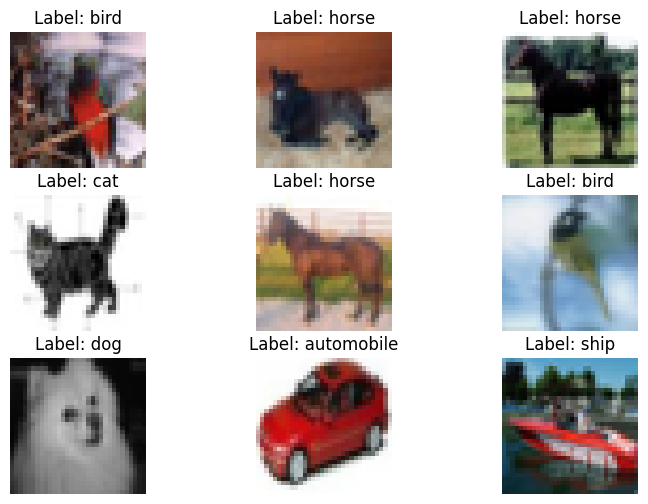

In [ ]:
# Class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Display 9 images from the training set and their labels
plt.figure(figsize=(9, 6))
for n in range(9):
    i = np.random.randint(0, len(X_train), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(X_train[i[0]])
    plt.title('Label: ' + class_names[y_train[i[0]][0]])
    plt.axis('off')

## Data Preprocessing

In [ ]:
# Normalize pixel values to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
# Print the shapes of data and label sets
print('Training data features', X_train.shape)
print('Training labels', y_train.shape)
print('Testing data features', X_test.shape)
print('Testing labels', y_test.shape)

Training data features (50000, 32, 32, 3)
Training labels (50000, 1)
Testing data features (10000, 32, 32, 3)
Testing labels (10000, 1)


## Load the ResNet Model

In [ ]:
# Load a pretrained ResNet50 model (without the top classification layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

In [ ]:
# Add custom classification head on top of the pretrained ResNet
inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
# Output layer - 10 classes
outputs = Dense(units=10, activation='softmax')(x)

In [ ]:
# Define the model by providing the inputs and outputs
model = Model(inputs, outputs)

## Train the ResNet Model

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Fit the model to the training dataset
history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.5290 - loss: 1.5985 - val_accuracy: 0.0952 - val_loss: 2.6101
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.6891 - loss: 1.0139 - val_accuracy: 0.2173 - val_loss: 2.7117
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.6840 - loss: 0.9770 - val_accuracy: 0.5353 - val_loss: 1.4401
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7451 - loss: 0.7635 - val_accuracy: 0.7171 - val_loss: 0.8835
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8225 - loss: 0.5278 - val_accuracy: 0.5228 - val_loss: 1.7669
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7955 - loss: 0.6012 - val_accuracy: 0.7394 - val_loss: 0.8048
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.8636 - loss: 0.4018 - val_accuracy: 0.5069 - val_loss: 1.6465
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.6810 - loss: 1.0346 -

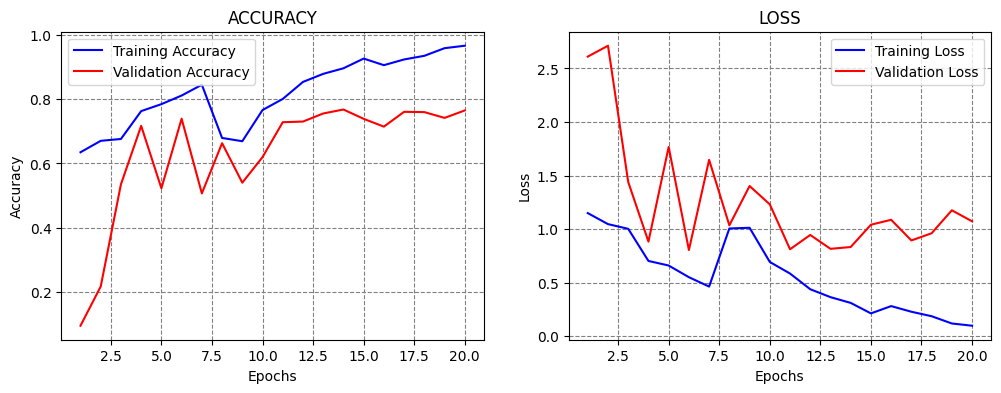

In [ ]:
# Plot the accuracy and loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1, 1)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochsn, train_loss, 'b', label='Training Loss')
plt.plot(epochsn, val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Evaluate the Model

In [ ]:
# Calculate and print the accuracy on the test dataset
evals_test = model.evaluate(X_test, y_test)
print(f"Accuracy on test dataset: {evals_test[1]*100:5.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7598 - loss: 1.1098
Accuracy on test dataset: 75.57%


In [ ]:
# Predict on test dataset
y_pred_probabilities = model.predict(X_test)
model_predictions = np.argmax(y_pred_probabilities, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step


In [ ]:
# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, model_predictions))

Confusion Matrix:
[[858   4  36  21  17   3   5   5  19  32]
 [ 36 749   5  12   0   4   7   0  22 165]
 [ 57   2 674  91  61  51  17  32   3  12]
 [ 26   4  35 729  29 111  18  29   2  17]
 [ 25   1  69 123 672  20  26  56   3   5]
 [ 11   2  41 245  21 607  12  47   4  10]
 [  9   4  58 111  10  26 770   5   0   7]
 [ 13   2  18  59  33  30   3 820   3  19]
 [126   8  13  26   6   2   7   0 789  23]
 [ 42  17   4  11   0   4   3   9  21 889]]


The confusion matrix shows the classification results for each object class (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck):
- Diagonal elements: Correctly classified images
- Off-diagonal elements: Misclassifications (showing which classes were confused with each other)